In [ ]:
!pip install pyxlsb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
dataframe = pd.read_excel('stc TV Data Set_T1.xlsb',sheet_name="Final_Dataset")
df=dataframe.copy()

In [ ]:
dataframe.shape

(1048575, 13)

In [ ]:
dataframe.head()

,Column1,date_,user_id_maped,program_name,duration_seconds,program_class,season,episode,program_desc,program_genre,series_title,hd,original_name
0,1,42882,26138,100 treets,40,MOVIE,0,0,Drama Movie100 Streets,Drama,0,0,100 treets
1,3,42876,7946,Moana,17,MOVIE,0,0,Animation MovieMoana (HD),Animation,0,1,Moana
2,4,42957,7418,The Mermaid Princess,8,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
3,5,42942,19307,The Mermaid Princess,76,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
4,7,42923,15860,Churchill,87,MOVIE,0,0,Biography MovieChurchill (HD),Biography,0,1,Churchill


In [ ]:
dataframe['program_name'] = dataframe['program_name'].str.strip()
dataframe['date_'] = pd.to_datetime(dataframe['date_'])
dataframe[['duration_seconds', 'season','episode','series_title','hd']] = dataframe[['duration_seconds', 'season','episode','series_title','hd']].apply(pd.to_numeric)
dataframe[['user_id_maped', 'program_name','program_class','program_desc','program_genre','original_name']] = dataframe[['user_id_maped', 'program_name','program_class','program_desc','program_genre','original_name']].astype(str)

In [ ]:
dataframe.head()

,Column1,date_,user_id_maped,program_name,duration_seconds,program_class,season,episode,program_desc,program_genre,series_title,hd,original_name
0,1,1970-01-01 00:00:00.000042882,26138,100 treets,40,MOVIE,0,0,Drama Movie100 Streets,Drama,0,0,100 treets
1,3,1970-01-01 00:00:00.000042876,7946,Moana,17,MOVIE,0,0,Animation MovieMoana (HD),Animation,0,1,Moana
2,4,1970-01-01 00:00:00.000042957,7418,The Mermaid Princess,8,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
3,5,1970-01-01 00:00:00.000042942,19307,The Mermaid Princess,76,MOVIE,0,0,Animation MovieThe Mermaid Princess (HD),Animation,0,1,The Mermaid Princess
4,7,1970-01-01 00:00:00.000042923,15860,Churchill,87,MOVIE,0,0,Biography MovieChurchill (HD),Biography,0,1,Churchill


In [ ]:
dataframe.describe()

,Column1,date_,duration_seconds,season,episode,series_title,hd
count,1.048575e+06,1048575,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,6.281730e+05,1970-01-01 00:00:00.000043012,1.230957e+03,1.342139e+00,6.157952e+00,1.205922e-02,3.862728e-01
min,1.000000e+00,1970-01-01 00:00:00.000042808,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.180660e+05,1970-01-01 00:00:00.000042896,5.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,6.303550e+05,1970-01-01 00:00:00.000043022,1.190000e+02,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
75%,9.398225e+05,1970-01-01 00:00:00.000043121,1.328000e+03,1.000000e+00,9.000000e+00,0.000000e+00,1.000000e+00
max,1.247852e+06,1970-01-01 00:00:00.000043220,1.461329e+06,2.300000e+01,2.820000e+02,1.000000e+00,1.000000e+00
std,3.597041e+05,NaN,6.821058e+03,2.104095e+00,1.222015e+01,1.091504e-01,4.868946e-01


In [ ]:
dataframe.isnull().any()

Column1             False
date_               False
user_id_maped       False
program_name        False
duration_seconds    False
program_class       False
season              False
episode             False
program_desc        False
program_genre       False
series_title        False
hd                  False
original_name       False
dtype: bool

In [ ]:
grouped=df.copy()
grouped.loc[grouped['program_class'] == 'SERIES/EPISODES', 'program_name'] = grouped['program_name']+'_SE'+grouped['season'].astype(str)+'_EP'+grouped['episode'].astype(str)
grouped = grouped.groupby(['program_name','program_class'])\
.agg({'user_id_maped': [('co1', 'nunique'),('co2', 'count')],\
      'duration_seconds': [('co3', 'sum')] }).reset_index()
grouped.columns = ['program_name','program_class','No of Users who Watched', 'No of watches', 'Total watch time in seconds']
grouped['Total watch time in houres']=grouped['Total watch time in seconds']/3600
grouped = grouped.drop(columns=['Total watch time in seconds'])
grouped = grouped.sort_values(by=['Total watch time in houres', 'No of watches','No of Users who Watched'], ascending=False).reset_index(drop=True)

In [ ]:
grouped.head(35)

,program_name,program_class,No of Users who Watched,No of watches,Total watch time in houres
0,The Boss Baby,MOVIE,3348,23625,2889.027778
1,The Expendables,MOVIE,853,2119,1961.159444
2,Moana,MOVIE,2112,7521,1540.544444
3,Trolls,MOVIE,2584,13609,1512.580278
4,Bean,MOVIE,949,3617,1423.955000
5,The murfs,MOVIE,726,2438,1190.363889
6,The Amazing pider-Man,MOVIE,650,1679,1157.005833
7,Cloudy With a Chance of Meatballs,MOVIE,683,2076,948.674722
8,Hotel Transylvania,MOVIE,375,1387,905.437778
9,The Amazing pider-Man,MOVIE,443,1087,782.467500


In [ ]:
import plotly.express as px

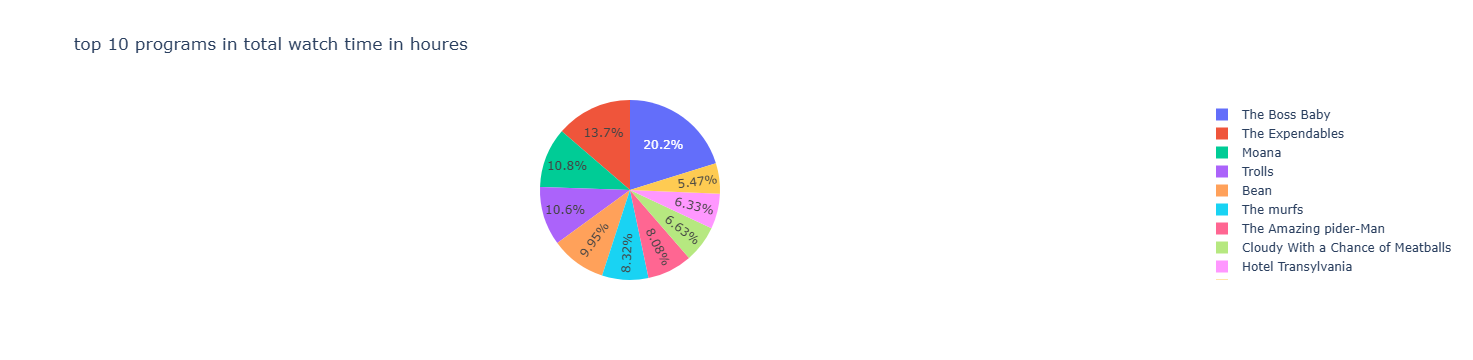

In [ ]:
fig = px.pie(grouped.head(10), values='Total watch time in houres', names='program_name',\
             hover_data=['program_class'],title='top 10 programs in total watch time in houres')
fig.show()

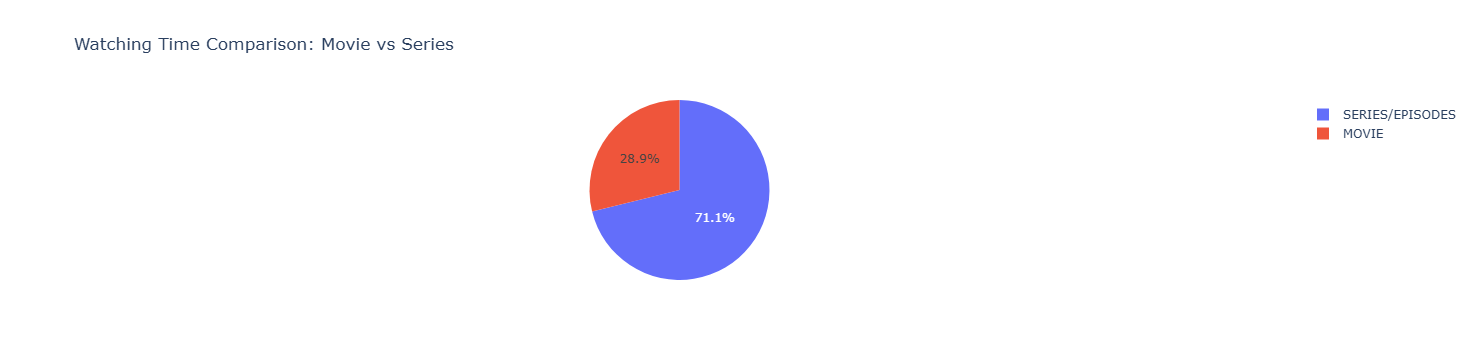

In [ ]:
fig_class = px.pie(grouped, values='Total watch time in houres', names='program_class',
                   title='Watching Time Comparison: Movie vs Series')
fig_class.show()

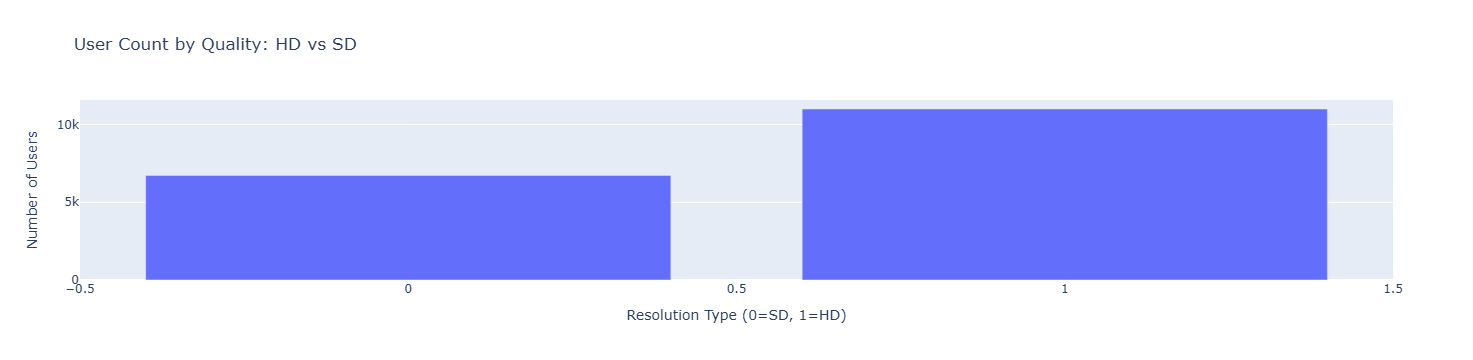

In [ ]:
quality_df = df.groupby('hd').agg({'user_id_maped': 'nunique'}).reset_index()

fig_quality = px.bar(quality_df, x='hd', y='user_id_maped',
                     labels={'hd': 'Resolution Type (0=SD, 1=HD)', 'user_id_maped': 'Number of Users'},
                     title='User Count by Quality: HD vs SD')
fig_quality.show()